# 2 · The report's seven models, reproduced
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/california-housing-ml/blob/main/notebooks/02_models_report.ipynb)

Same features (9 numeric + one-hot `ocean_proximity`), the same 80/20 split (seed 42), the same final hyperparameters.
Every pipeline standardises the numeric features.

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/california-housing-ml
    %cd california-housing-ml/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
os.environ["PYTHONWARNINGS"] = "ignore"  # parallel CV workers don't inherit warnings filters
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from housing import plots
plots.use_style()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
from housing.data import split
from housing import models as m
s = split()
print(f'train {len(s.X_train):,} · test {len(s.X_test):,}')

train 15,714 · test 3,929


In [2]:
table = m.compare(m.report_models(), s)
table.round(4).to_csv("../reports/model_comparison_report.csv", index=False)
table.round(4)

,Model,R2 Train,R2 Test,RMSE Test,MAE Test,Train Time (s),Gap
0,Gradient Boosting,0.7717,0.7074,52311.5045,37563.0052,6.0068,0.0642
1,Random Forest,0.9341,0.7063,52410.7853,37759.8188,3.8193,0.2278
2,Neural Network (MLP),0.6803,0.6796,54747.3187,39431.6296,3.7731,0.0007
3,Linear Regression (OLS),0.6111,0.6180,59771.7976,44381.5849,0.0051,-0.0070
4,Ridge,0.6111,0.6180,59771.8471,44387.3347,0.1138,-0.0070
5,Lasso,0.6110,0.6179,59783.9028,44415.4300,20.6951,-0.0069
6,SVR,0.5853,0.5994,61209.1703,43638.7051,2.5587,-0.0141


Report Table 2 for comparison: OLS 0.618 · Ridge 0.618 · Lasso 0.6179 · RF 0.7063 · GB 0.7071 · SVR 0.5994 ·
MLP 0.6796. Six models match to four decimals. Gradient boosting differs by 0.0003 (floating-point differences
between Colab and this machine).

## Final model (report section "Final Model")
Gradient boosting with learning rate 0.025 and depth 7.

{'Model': 'Final gradient boosting', 'R2 Train': 0.8119, 'R2 Test': 0.7076, 'RMSE Test': 52299.0235, 'MAE Test': 37376.2535, 'Train Time (s)': 7.9894} (report: R² 0.7078)


median_income                 0.503
ocean_proximity_INLAND        0.185
population_per_household      0.133
housing_median_age            0.054
bedrooms_per_room             0.031
rooms_per_household           0.026
total_bedrooms                0.015
total_rooms                   0.015
population                    0.014
households                    0.013
ocean_proximity_NEAR OCEAN    0.005
ocean_proximity_<1H OCEAN     0.003
ocean_proximity_NEAR BAY      0.003
dtype: float64

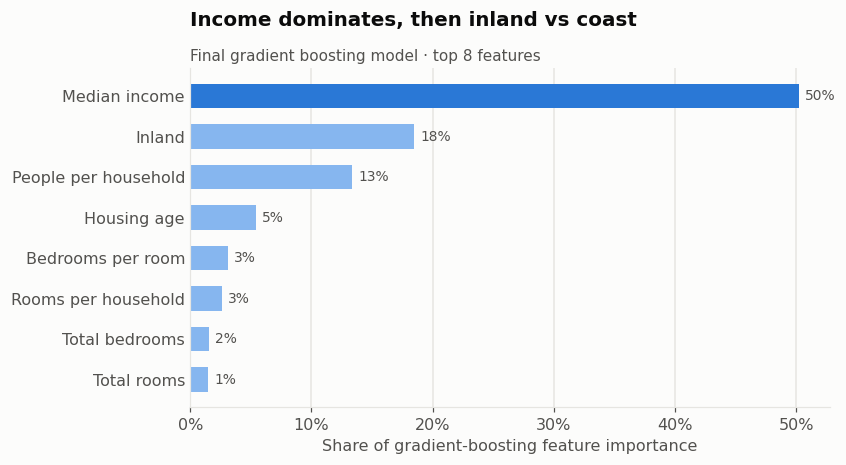

In [3]:
final = m.final_gradient_boosting()
result = m.evaluate("Final gradient boosting", final, s.X_train, s.y_train, s.X_test, s.y_test)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in result.items()}, "(report: R² 0.7078)")
imp = m.importances(final)
fig = plots.importances(imp); plots.save(fig, "feature_importance")
imp.round(3)

Median income carries about half of the importance. The `INLAND` flag comes next, then people per household.
The finer coastal categories add almost nothing once inland vs coast is known.